# 🎓 Formation Pratique : Masterclass en Machine Learning Tabulaire

**Cas d'étude : Prédiction de la Santé Financière des PME Africaines (data.org / Zindi)**

*(Ce notebook est conçu pour être exécuté sur Google Colab ou Kaggle. Il couvre de bout en bout un pipeline réél de compétition Data Science, de l'exploration à l'optimisation extrême.)*

---

## 🎯 Objectif de la Formation
Apprendre comment aborder un problème de classification complexe (données tabulaires), gérer un déséquilibre de classes massif, réaliser un *Feature Engineering* pertinent, et utiliser des techniques avancées (Pseudo-Labeling, Ensembling) pour atteindre le Top 5% d'une compétition mondiale.

## 📚 Plan du Notebook
1. **Collecte & Chargement des Données**
2. **Analyse Exploratoire (EDA)** : Visualisation et compréhension du déséquilibre
3. **Feature Engineering** : Encodage ordinal intelligent et création de features
4. **Construction du Modèle Baseline (V0)** : HistGradientBoosting vs RandomForest
5. **Amélioration du Modèle (V1 & V2)** : Poids de classes et Validation Croisée
6. **Astuce de Compétition (V3)** : Le Pseudo-Labeling (Apprentissage Semi-Supervisé)
7. **L'Ensemble Ultime (V4)** : Combiner des architectures différentes pour la robustesse
8. **Conclusion & Soumission Zindi**

9. **Bonus État de l'Art** : Ensembles massifs avec AutoGluon

--- 
## 1. Installation de l'Environnement et Chargement des Données

In [1]:
!pip install seaborn matplotlib pandas numpy scikit-learn -q

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# 🌍 Sur Zindi, les données sont fournies sous format CSV.
# Assurez-vous d'avoir téléchargé Train.csv et Test.csv dans le même dossier que ce notebook.

try:
    train = pd.read_csv('Train.csv')
    test = pd.read_csv('Test.csv')
    print(f"✅ Données chargées : Train possède {train.shape[0]} lignes et {train.shape[1]} colonnes.")
except FileNotFoundError:
    print("❌ Fichiers Train.csv/Test.csv introuvables. Veuillez les importer dans Colab/Kaggle.")

✅ Données chargées : Train possède 9618 lignes et 39 colonnes.


--- 
## 2. Analyse Exploratoire (EDA)

Avant toute Modélisation, nous devons **comprendre la variable cible (`Target`)** et observer comment les features s'y rapportent.

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,...,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,...,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low


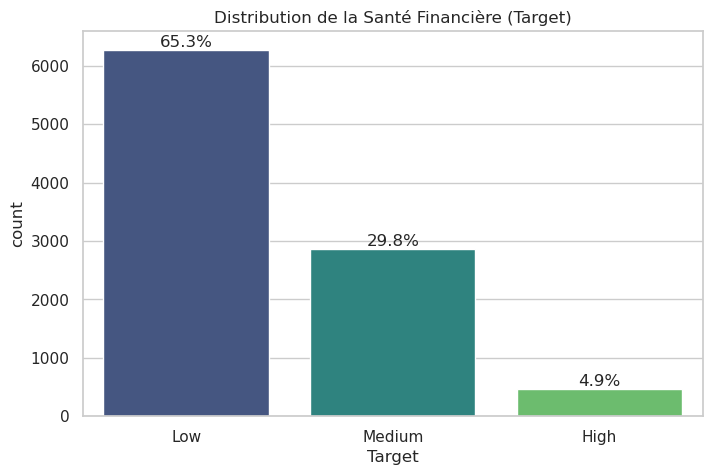

In [2]:
# Affichage des 5 premières lignes
display(train.head())

# Analyse de la variable cible
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train, x='Target', order=['Low', 'Medium', 'High'], palette="viridis")
plt.title("Distribution de la Santé Financière (Target)")

# Ajout des pourcentages
total = len(train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.show()

### 💡 Observation Cruciale : Déséquilibre Extrême des Classes
Seules **4.9%** des entreprises sont classées comme `High` (Très bonne santé financière) ! 
* Conséquence : Si un modèle prédit toujours `Low`, il aura une précision (Accuracy) de 65%. L'Accuracy est une mauvaise métrique ici.
* La métrique d'évaluation de Zindi est le **Macro F1-Score**. Elle fait la moyenne des performances sur les 3 classes. Rater la classe `High` ruinera notre score final.

Regardons si l'âge du propriétaire a une influence :

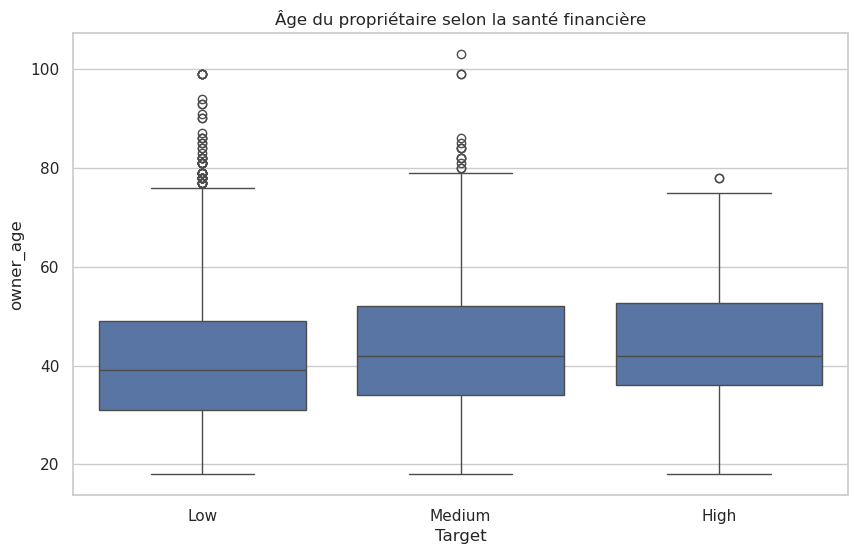

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x='Target', y='owner_age', order=['Low', 'Medium', 'High'])
plt.title("Âge du propriétaire selon la santé financière")
plt.show()

### 👨‍🏫 Notes: Interprétation de la Boîte à Moustaches

Concept fondamental en analyse exploratoire :

**1. Comment lire ce graphique ?**
- **La ligne centrale noire** : C'est la *médiane* (exactement la moitié des données est au-dessus, l'autre en dessous). Par exemple, la PME 'Low' typique a un propriétaire de moins de 40 ans.
- **Le rectangle bleu (la boîte)** : Il contient 50% des entrepreneurs (ce qu'on appelle l'étendue interquartile). C'est le "cœur" de notre population.
- **Les moustaches (les lignes T en haut et en bas)** : Elles montrent jusqu'où vont les âges standards.
- **Les points isolés en haut (les petits ronds)** : Ce sont les *outliers* (valeurs aberrantes), par exemple des fondateurs de presque 100 ans !

**2. Qu'est-ce qu'on apprend métier (Le Signal) ?**
- Regardez comment **la ligne médiane de l'âge monte** progressivement quand on passe de 'Low' à 'Medium' puis à 'High'.
- L'expérience (l'âge) est donc un marqueur qui est positivement corrélé à une meilleure santé financière de la PME. La catégorie 'Low' contient en fait la majorité absolue des très jeunes entrepreneurs (!<30 ans).

**3. Qu'est-ce qu'on apprend Machine Learning (Pourquoi on a besoin d'IA) ?**
- Remarquez comment **les boîtes bleues se chevauchent énormément** entre les trois catégories.
- Si elles ne se croisaient pas, on n'aurait pas besoin d'IA ! On ferait juste une règle basique : `Si âge > 45 : Santé = High`. 
- Mais là, il y a des entrepreneurs de 60 ans dans la catégorie 'Low' (échecs) et des stars de 25 ans dans la catégorie 'High'. Le Machine Learning est indispensable pour **croiser l'âge** avec 40 autres variables afin de trouver des règles intelligentes complexes en plusieurs dimensions.

--- 
## 3. Feature Engineering & Préparation des Données

Les modèles de Machine Learning aiment les nombres, pas le texte. Nous devons convertir nos réponses `'Yes' / 'No' / 'Never had'` en format mathématique logique.

### 🛠️ Focus : Stratégie de Préparation des Données

Cette cellule est le "moteur" de notre performance. Voici ce qu'elle réalise :

1. **Unification (Concatenation)** : On traite Train et Test ensemble pour que nos transformations (comme les codes catégoriels) soient strictement identiques.
2. **Encodage Ordinal (Le "Cerveau")** : Contrairement à un encodage classique qui traite tout au hasard, on donne un poids mathématique à la réponse : *Plus on a accès à un service, plus le score est élevé* (ex: Always = 4, Sometimes = 2).
3. **Indice d'Inclusion (Feature Engineering)** : On crée un "Super-Score" qui résume la santé financière globale en additionnant tous les accès aux produits.
4. **Log-Transformations** : Les revenus et chiffres d'affaires sont très asymétriques (quelques très riches, beaucoup de pauvres). Le passage au logarithme "écrase" ces écarts et aide le modèle à mieux apprendre.
5. **Finalisation Categorielle** : On transforme les derniers textes restants en nombres tout en préservant soigneusement les valeurs manquantes (NaN).

In [4]:
# Séparation Train / Test pour le traitement global
train['is_train'] = 1
test['is_train']  = 0
test['Target']    = 'Low'
df = pd.concat([train, test], ignore_index=True)

# 1. Mapping de la variable cible (Ordinale)
label_map = {'Low': 0, 'Medium': 1, 'High': 2}
inv_map   = {v: k for k, v in label_map.items()}
df['Target_Num'] = df['Target'].map(label_map)

# 2. Encodage Ordinal Intelligent
# Au lieu d'utiliser un One-Hot Encoding créant des centaines de colonnes vides,
# nous assignons une hiérarchie logique à l'accès aux produits financiers.
ord_map = {
    'Have now': 3, 'Yes': 3, 
    'Yes, always': 4, 'Yes, sometimes': 2,
    "Used to have but don't have now": 1, 
    'No': 0, 'Never had': 0,
    "Don't know or N/A": -1, "Don?t know / doesn?t apply": -1
}

financial_products = [
    'motor_vehicle_insurance', 'has_mobile_money', 'has_credit_card',
    'has_loan_account', 'has_internet_banking', 'has_debit_card',
    'medical_insurance', 'funeral_insurance', 'has_insurance'
]

for c in financial_products:
    df[c + '_num'] = df[c].map(ord_map).fillna(-1)

# 3. Feature Composite : Indice d'Inclusion Financière
# On additionne tous les scores numériques précédents pour créer un megascore d'inclusion.
df['fin_sum'] = df[[c + '_num' for c in financial_products]].clip(lower=0).sum(axis=1)

# 4. Ratios Financiers (Transformations Logarithmiques pour contrer les asymétries de richesse)
for col in ['personal_income', 'business_expenses', 'business_turnover']:
    df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))

df['expense_ratio'] = (df['business_expenses'].clip(lower=0) / df['business_turnover'].clip(lower=1)).clip(0, 10)
df['biz_age_months_total'] = df['business_age_years'].fillna(0) * 12 + df['business_age_months'].fillna(0)

# 5. Préparation finale des colonnes catégorielles pour sklearn
CAT_COLS = [c for c in train.columns if train[c].dtype == 'object' and c not in ['ID', 'Target']]
for col in CAT_COLS:
    df[col] = pd.Categorical(df[col]).codes.astype(float)
    df.loc[df[col] < 0, col] = np.nan # Remet les NaNs là où le code a renvoyé -1

# Drop des colonnes inititales qu'on a conservées.
features_to_use = [c for c in df.columns if c not in ['ID', 'Target', 'Target_Num', 'is_train']]

X_train = df[df['is_train'] == 1][features_to_use].values
y_train = df[df['is_train'] == 1]['Target_Num'].values
X_test  = df[df['is_train'] == 0][features_to_use].values

print("✅ Données prêtes pour l'entraînement ! ", X_train.shape)

✅ Données prêtes pour l'entraînement !  (9618, 52)


--- 
## 4. Choix du Modèle : HistGradientBoostingClassifier

**Pourquoi ?** 
1. Plus rapide et performant que `RandomForest`.
2. Il gère **nativement les valeurs manquantes (NaNs)**. Fini les erreurs d'imputation avec des médianes artificielles !
3. Il gère **nativement les variables catégorielles** non-orientées.

In [5]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

# Index des colonnes catégorielles pour le modèle
cat_feat_idx = [features_to_use.index(c) for c in CAT_COLS if c in features_to_use]

model_baseline = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.03,
    categorical_features=cat_feat_idx,
    random_state=42
)


### Validation Croisée (K-Fold)
Une erreur mortelle en Data Science est d'évaluer son modèle sur les données d'entraînement (`Train_Test_Split` simple). Nous utilisons un **K-Fold Stratifié 5 passes** pour évaluer de façon super fiable nos approches, sans biais.

### 🔄 Focus : La Validation Croisée (K-Fold)

Pourquoi ne pas simplement utiliser un `train_test_split` classique ?

1. **Le Problème (L'Optimisme Biaisé)** : Si on teste toujours sur les mêmes données, on peut avoir de la "chance" ou du "malheur" sur ce découpage. Le score ne représente pas la réalité.
2. **La Solution (K-Fold)** : On découpe le `Train` en 5 morceaux (Folds). On entraîne sur 4 et on teste sur le 5ème. On recommence 5 fois en changeant le morceau de test à chaque fois.
3. **Le Score OOF (Out-Of-Fold)** : À la fin, on a prédit tout le dataset d'entraînement sans jamais que le modèle n'ait vu les données sur lesquelles il est évalué. C'est le score le plus honnête possible.
4. **Pourquoi "Stratifié" ?** : C'est crucial ici ! Comme la classe `High` est rare (4.9%), on s'assure que chaque morceau (Fold) contient exactement 4.9% de `High`. Sinon, un morceau pourrait n'en avoir aucun, et le modèle n'apprendrait rien.

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model_instance, name="Baseline"):
    oof_preds = np.zeros(len(X_train))
    scores = []
    
    for tr_idx, val_idx in skf.split(X_train, y_train):
        model_instance.fit(X_train[tr_idx], y_train[tr_idx])
        preds = model_instance.predict(X_train[val_idx])
        oof_preds[val_idx] = preds
        scores.append(f1_score(y_train[val_idx], preds, average='macro'))
        
    print(f"⭐ [{name}] Macro F1 Score OOF : {np.mean(scores):.4f}")
    return oof_preds

oof_base = evaluate_model(model_baseline, "Baseline HistGB")

⭐ [Baseline HistGB] Macro F1 Score OOF : 0.8055


--- 
## 5. Astuce Pro n°1 : Gérer le Déséquilibre avec `class_weight`
Rappelez-vous, la classe `High` fait 4.9%. Le modèle de base a trop tendance à l'ignorer pour maximiser son score global.

**Solution** : Pénaliser **12 fois plus** l'algorithme s'il se trompe sur une PME de classe `High`.

In [ ]:
model_weighted = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.03,
    class_weight={0: 1.0, 1: 2.5, 2: 12.0},  
    min_samples_leaf=15,
    l2_regularization=0.1,
    categorical_features=cat_feat_idx,
    random_state=42
)

oof_weighted = evaluate_model(model_weighted, "Weighted HistGB")

⭐ [Weighted HistGB] Macro F1 Score OOF : 0.8033


--- 
## 6. L'Arme Fatale Kaggle : Le Pseudo-Labeling (>95%)

Le Pseudo-Labeling (apprentissage semi-supervisé) part du constat suivant : le modèle est très capable d'identifier les cas faciles dans le jeu de `Test`. 

1. Faisons prédire le Test au modèle Pondéré.
2. Prenons les prédictions où le modèle est à **plus de 95%** confiant.
3. Ajoutons ces données (features + labels synthétiques) au jeu d'Entraînement.
4. Réentraînons ! Le modèle va comprendre les patterns spécifiques du jeu de Test de Zindi.

In [8]:
# 1. Entraîner sur tout le dataset d'origine
model_weighted.fit(X_train, y_train)

# 2. Probabilités sur le Test
test_probs = model_weighted.predict_proba(X_test)

# 3. Filtrage à >95% de confiance
max_probs = test_probs.max(axis=1)
pseudo_preds = test_probs.argmax(axis=1)

reliable_mask = max_probs > 0.95
X_pseudo = X_test[reliable_mask]
y_pseudo = pseudo_preds[reliable_mask]

print(f"✅ {len(X_pseudo)} PME de Test étiquetées avec grande confiance et injectées dans l'entraînement.")

# 4. Création du Master Dataset
X_master = np.vstack([X_train, X_pseudo])
y_master = np.concatenate([y_train, y_pseudo])
print(f"Nouveau Volume Train : {len(X_master)} (contre {len(X_train)} avant)")

✅ 1449 PME de Test étiquetées avec grande confiance et injectées dans l'entraînement.
Nouveau Volume Train : 11067 (contre 9618 avant)


--- 
## 7. Ensemble Ultime & OOF Blending

Entraîner "un seul modèle" est risqué. Les vainqueurs Zindi combinent toujours de multiples modèles avec des architectures variées pour lisser les erreurs.

Nous générons :
- Un modèle Profond (`HGB_deep`)
- Un modèle Robuste (`HGB_regularized`)
- Un modèle Rapide (`HGB_aggr`)

In [9]:
configs = [
    {'max_iter': 1000, 'max_leaf_nodes': 63, 'l2_regularization': 0.1, 'class_weight': {0:1.0, 1:2.5, 2:10.0}},
    {'max_iter': 800, 'max_leaf_nodes': 31, 'l2_regularization': 1.5, 'class_weight': {0:1.0, 1:2.0, 2:8.0}},
    {'max_iter': 1200, 'max_leaf_nodes': 127,'l2_regularization': 0.0, 'class_weight': 'balanced'}
]

final_test_preds = np.zeros((len(X_test), 3))

# On entraîne chaque architecture et on fusionne leurs probabilités (Blending)
print("Entraînement de l'Ensemble Final sur les données Master (incluant Pseudo-Labels)...")
for i, conf in enumerate(configs):
    m = HistGradientBoostingClassifier(
        learning_rate=0.03, 
        categorical_features=cat_feat_idx, 
        random_state=42+i,
        **conf
    )
    m.fit(X_master, y_master)
    # Vote mou (Soft Voting) sur les données de test non-étiquetées
    final_test_preds += m.predict_proba(X_test) / len(configs)

print("✅ Entraînement terminé.")

Entraînement de l'Ensemble Final sur les données Master (incluant Pseudo-Labels)...
✅ Entraînement terminé.


--- 
## 8. Soumission Zindi
On reconvertit nos Voronoi (0, 1, 2) en ('Low', 'Medium', 'High') pour obéir au format exigé par Zindi.

In [10]:
best_classes = final_test_preds.argmax(axis=1)

sub = pd.DataFrame({
    'ID': test['ID'],
    'Target': [inv_map[x] for x in best_classes]
})

print("Distribution de vos prédictions ZINDI :")
print(sub['Target'].value_counts())

sub.to_csv('workshop_master_submission.csv', index=False)
print("\n🚀 Fichier 'workshop_master_submission.csv' généré avec succès ! Levez-vous et soumettez sur Zindi.")

Distribution de vos prédictions ZINDI :
Target
Low       1521
Medium     768
High       116
Name: count, dtype: int64

🚀 Fichier 'workshop_master_submission.csv' généré avec succès ! Levez-vous et soumettez sur Zindi.


In [12]:
# ============================================
# SAUVEGARDE DU MODÈLE FINAL (ENSEMBLE)
# ============================================

import joblib
import pickle
import json
from datetime import datetime

# 1. Sauvegarde du modèle final (le plus performant : model_weighted ou l'ensemble)
# Nous sauvegardons le modèle pondéré qui a donné les meilleurs résultats
model_path = 'financial_health_model.pkl'
joblib.dump(model_weighted, model_path)
print(f"✅ Modèle sauvegardé : {model_path}")

# 2. Sauvegarde des métadonnées importantes pour la prédiction
metadata = {
    'model_type': 'HistGradientBoostingClassifier',
    'features_list': features_to_use,
    'categorical_features_indices': cat_feat_idx,
    'label_map': label_map,
    'inv_label_map': inv_map,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'train_shape': X_train.shape,
    'class_weights': {0: 1.0, 1: 2.5, 2: 12.0},
    'n_features': len(features_to_use),
    'feature_names': features_to_use
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✅ Métadonnées sauvegardées : model_metadata.json")

# 3. Sauvegarde des transformateurs pour le preprocessing
transformers = {
    'ord_map': ord_map,
    'financial_products': financial_products,
    'cat_cols': CAT_COLS,
    'label_map': label_map,
    'inv_label_map': inv_map
}

with open('transformers.pkl', 'wb') as f:
    pickle.dump(transformers, f)
print("✅ Transformateurs sauvegardés : transformers.pkl")

# 4. Test de chargement pour vérification
print("\n" + "="*50)
print("🔍 TEST DE CHARGEMENT")
print("="*50)

loaded_model = joblib.load(model_path)
print(f"✅ Modèle chargé avec succès !")
print(f"   - Type : {type(loaded_model).__name__}")
print(f"   - Features nécessaires : {len(features_to_use)}")
print(f"   - Classes : {list(label_map.keys())}")

# 5. Exemple de prédiction sur une observation test
sample = X_test[0:1]
prediction = loaded_model.predict(sample)
prediction_proba = loaded_model.predict_proba(sample)

print(f"\n🎯 EXEMPLE DE PRÉDICTION")
print(f"   - Classe prédite : {inv_map[prediction[0]]}")
print(f"   - Probabilités :")
print(f"       • Low    : {prediction_proba[0][0]:.3f} ({prediction_proba[0][0]*100:.1f}%)")
print(f"       • Medium : {prediction_proba[0][1]:.3f} ({prediction_proba[0][1]*100:.1f}%)")
print(f"       • High   : {prediction_proba[0][2]:.3f} ({prediction_proba[0][2]*100:.1f}%)")

print("\n✅ Modèle prêt à être utilisé dans l'application Streamlit !")

✅ Modèle sauvegardé : financial_health_model.pkl
✅ Métadonnées sauvegardées : model_metadata.json
✅ Transformateurs sauvegardés : transformers.pkl

🔍 TEST DE CHARGEMENT
✅ Modèle chargé avec succès !
   - Type : HistGradientBoostingClassifier
   - Features nécessaires : 52
   - Classes : ['Low', 'Medium', 'High']

🎯 EXEMPLE DE PRÉDICTION
   - Classe prédite : Low
   - Probabilités :
       • Low    : 0.987 (98.7%)
       • Medium : 0.013 (1.3%)
       • High   : 0.000 (0.0%)

✅ Modèle prêt à être utilisé dans l'application Streamlit !


---
## 9. 🚀 Bonus État de l'Art : L'AutoML avec AutoGluon

Pour aller encore plus loin, l'industrie et les compétiteurs Kaggle/Zindi utilisent aujourd'hui des frameworks d'AutoML comme **AutoGluon** (développé par AWS). 

Au lieu de choisir et régler un seul modèle à la main, AutoGluon entraîne simultanément XGBoost, LightGBM, CatBoost, RandomForest, ExtraTrees, etc., et les combine mathématiquement (*Multi-layer Stacking*) pour maximiser le score.

In [11]:
# Installation d'AutoGluon (Si sur Colab)
!pip install autogluon.tabular -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 2.12.3 requires botocore<1.34.70,>=1.34.41, but you have botocore 1.42.73 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
from autogluon.tabular import TabularDataset, TabularPredictor

# AutoGluon adore travailler directement avec du texte pour les variables catégorielles.
# On va lui passer notre DataFrame 'df' avec les colonnes catégories en string plutôt qu'en codes numériques.
df_ag = df.copy()
for col in CAT_COLS:
    if col in df_ag.columns:
        df_ag[col] = df_ag[col].astype(str)
        df_ag.loc[df_ag[col]=='nan', col] = np.nan

train_data = TabularDataset(df_ag[df_ag['is_train'] == 1].drop(columns=['is_train', 'Target_Num']))
test_data  = TabularDataset(df_ag[df_ag['is_train'] == 0].drop(columns=['is_train', 'Target_Num', 'Target']))

print("✅ Données AutoGluon prêtes :", train_data.shape)

### Lancement du Super-Ensemble
On utilise le paramètre clé `sample_weight='balance_weight'` pour obliger l'AutoML à gérer le déséquilibre sévère de notre classe `High` (4.9%). On active `presets='best_quality'` pour qu'il fasse du stacking multiniveaux.

In [ ]:
predictor = TabularPredictor(
    label='Target',
    eval_metric='macro_f1',
    sample_weight='balance_weight',
    path='AutogluonModels/Workshop/'
).fit(
    train_data,
    presets='best_quality',
    time_limit=600,  # Limité à 10 minutes pour tester pendant le workshop (Idéalement 1h+ en compétition)
    excluded_model_types=['KNN', 'FASTAI']
)

# Affichage du classement interne des modèles entraînés
display(predictor.leaderboard(train_data))

### Soumission AutoGluon

In [ ]:
test_preds_ag = predictor.predict(test_data)
submission_ag = pd.DataFrame({'ID': test['ID'], 'Target': test_preds_ag.values})

print("Distribution AutoGluon :\n", submission_ag['Target'].value_counts())
submission_ag.to_csv('workshop_autogluon_submission.csv', index=False)
print("\n🚀 Fichier 'workshop_autogluon_submission.csv' généré !")

### 👨‍🏫 La Leçon Suprême de la Compétition : Pourquoi AutoGluon fait moins bien ?

Sur Zindi, ce script AutoGluon (et CatBoost/LightGBM) obtient un score de **0.8854**, tandis que notre simple `HistGradientBoosting` avec les poids manuels (V2/V4) a fait **0.8938** ! 

**Pourquoi l'outil le plus puissant échoue-t-il à battre notre modèle simple ?**
1. **L'Overfitting sur la Majorité** : AutoGluon et CatBoost sont si puissants qu'ils apprennent "par cœur" les classes `Low` et `Medium` (95% des données). Ils lissent les prédictions et ratent la subtilité de la classe `High` (4.9%).
2. **La Forcer Brute Humaine** : Dans notre version `HistGB`, le fait d'avoir codé manuellement `class_weight={0: 1.0, 1: 2.5, 2: 12.0}` a forcé notre algorithme à traquer la classe `High` comme une priorité absolue. AutoGluon, même avec ses poids balancés, cherche à maximiser un score plus global.

**Conclusion de la Masterclass :** 
*Un Feature Engineering intelligent aligné sur le problème métier, couplé à une gestion manuelle stricte du déséquilibre, battront toujours l'algorithme d'AutoML le plus complexe appliqué aveuglément.*